In [3]:
# python
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

In [3]:
client = scaleout.make_dask_client("tls://localhost:8786")
client

Connection method: Direct,
Dashboard: /user/knh3dg@virginia.edu/proxy/8787/status,
Comm: tls://192.168.121.140:8786,Workers: 0
Dashboard: /user/knh3dg@virginia.edu/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [4]:
 samples = [
   "TTJets", 

]
fileset = utilities.make_fileset(samples, 
                                 "llpNanoAOD_v2", 
                                 location_cfg="backgrounds.yaml",
                                 # max_files =100
                                  max_files = -1
                                )


runner = processor.Runner(
    #executor=processor.IterativeExecutor(),
    executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    '2mu_2LJ_CCnocharge',
    '2mu_2LJ_CC',
    '2LJ_CCnocharge',
    '2LJ_CC',
    'only2mu_2LJ_CCnocharge',
    'only2mu_2LJ_CC',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]



Output()

Processing TTJets


Output()

TTJets is simulation. Scaling histograms or cutflows according to lumi*xs.


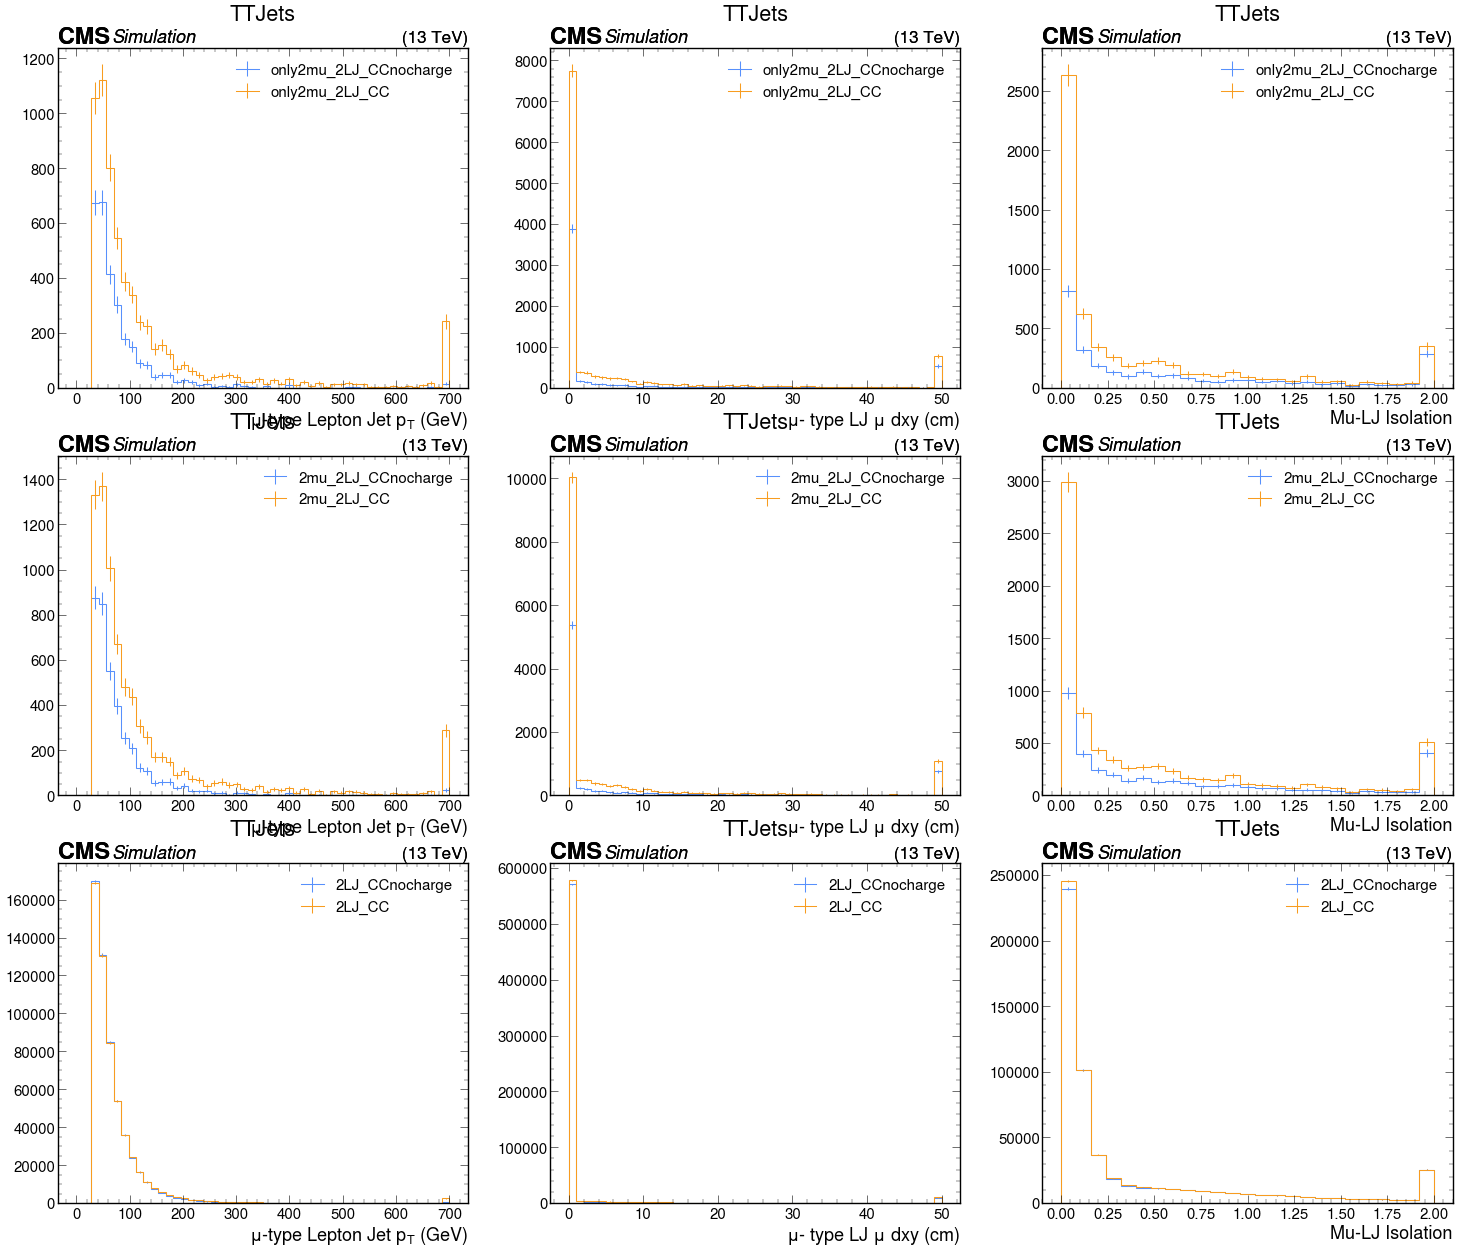

In [33]:
channel = [['only2mu_2LJ_CCnocharge','only2mu_2LJ_CC'],['2mu_2LJ_CCnocharge','2mu_2LJ_CC'],['2LJ_CCnocharge','2LJ_CC']]
plt.subplots(len(channel), 3, figsize=(36,10*len(channel)))
for i in range(len(channel)):
    plt.subplot(len(channel), 3, 1+i*3)
    channel1 = channel[i][0]
    channel2 = channel[i][1]
    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel1, ::2j],label=channel1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_pt"][channel2, ::2j],label=channel2)
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[0],y=1.07)

    plt.subplot(len(channel), 3, 2+i*3)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channel1, ::2j],label=channel1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_muon_dxy"][channel2, ::2j],label=channel2)
    plt.legend()
    plt.title(samples[0],y=1.07)

    plt.subplot(len(channel), 3, 3+i*3)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channel1, ::2j],label=channel1)
    utilities.plot(out[samples[0]]["hists"]["mu_lj_isolation"][channel2, ::2j],label=channel2)
    #plt.yscale("log")
    plt.legend()
    plt.title(samples[0],y=1.07)


The above graphs compare the amount of TTjet background that makes it through cross cleaning with and without a charge requirement. The graphs in the middle require two lepton jets with greater than or equal to two muons in the lepton jet, which mimics our selections for the final analysis. Notice that the addition of a charge requirment increases background by around 2x. This can be confirmed in the cell below. 

In [31]:
#number of lepton jets in each case
compare = ['mu_lj_muonN']

for i in compare:
    print(i)
    for j in range(len(channels)//2):
        print(f'{channels[2*j+1]} / {channels[2*j]}: {out[samples[0]]["hists"][i][2*j+1, ::].values(flow=True).sum() / out[samples[0]]["hists"][i][2*j, ::].values(flow=True).sum()}')
        print("")
    print("")
    

mu_lj_muonN
2mu_2LJ_CC / 2mu_2LJ_CCnocharge: 2.018593371059014

2LJ_CC / 2LJ_CCnocharge: 1.0121924992141877

only2mu_2LJ_CC / only2mu_2LJ_CCnocharge: 2.1492537313432836




In [4]:
samples = [    
    '2Mu2E_100GeV_0p25GeV_0p2mm',
    '2Mu2E_100GeV_0p25GeV_10p0mm',
    '2Mu2E_100GeV_0p25GeV_20p0mm',
    
    '2Mu2E_100GeV_1p2GeV_0p96mm',
    '2Mu2E_100GeV_1p2GeV_48p0mm',
    '2Mu2E_100GeV_1p2GeV_96p0mm',
    
    '2Mu2E_100GeV_5p0GeV_4p0mm',
    '2Mu2E_100GeV_5p0GeV_200mm',
    '2Mu2E_100GeV_5p0GeV_400mm',

    '2Mu2E_500GeV_0p25GeV_0p04mm',
    '2Mu2E_500GeV_0p25GeV_2p0mm',
    '2Mu2E_500GeV_0p25GeV_4p0mm',

    '2Mu2E_500GeV_1p2GeV_0p19mm',
    '2Mu2E_500GeV_1p2GeV_9p6mm',
    '2Mu2E_500GeV_1p2GeV_19p0mm',

    '2Mu2E_500GeV_5p0GeV_0p8mm',
    '2Mu2E_500GeV_5p0GeV_40p0mm',
    '2Mu2E_500GeV_5p0GeV_80p0mm',
    
    '2Mu2E_1000GeV_0p25GeV_0p02mm',
    '2Mu2E_1000GeV_0p25GeV_1p0mm',
    '2Mu2E_1000GeV_0p25GeV_2p0mm',

    '2Mu2E_1000GeV_1p2GeV_0p096mm',
    '2Mu2E_1000GeV_1p2GeV_4p8mm',
    '2Mu2E_1000GeV_1p2GeV_9p6mm',

    '2Mu2E_1000GeV_5p0GeV_0p4mm',
    '2Mu2E_1000GeV_5p0GeV_20p0mm',
    '2Mu2E_1000GeV_5p0GeV_40p0mm',
]

fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="signal_2mu2e_v10.yaml")

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
    '2mu_2LJ_CCnocharge',
    '2mu_2LJ_CC',
    '2LJ_CCnocharge',
    '2LJ_CC',
    'only2mu_2LJ_CCnocharge',
    'only2mu_2LJ_CC',
]

p = sidm_processor.SidmProcessor(
    channels,
    ["genA_toMu_base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

Output()

Processing 2Mu2E_100GeV_0p25GeV_0p2mm


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

...

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1159: UserWarning: Performed attempt 2 out of 
4
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1159: UserWarning: Performed attempt 3 out of 
4
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/processor/executor.py:1159: UserWarning: Performed attempt 4 out of 
4
  warnings.warn(

Exception: Failed processing file: WorkItem(dataset='2Mu2E_100GeV_0p25GeV_0p2mm', filename='root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo2Mu2e/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-100_MDp-0p25_ctau-0p2_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo2Mu2e_MBs-100_MDp-0p25_ctau-0p2_v3_part-0.root', treename='Events', entrystart=0, entrystop=2887, fileuuid=b'\xae\xbcx\xce\xbc\xfe\x11\xef\x85o\x90\x15\xe6\x9b\xbe\xef', usermeta={'year': '2018', 'is_data': False, 'skim_factor': 1.0}). The error was: KeyError('genAs_toMu_lxy_highRange').

In [ ]:
channel = [['only2mu_2LJ_CCnocharge','only2mu_2LJ_CC'],['2mu_2LJ_CCnocharge','2mu_2LJ_CC'],['2LJ_CCnocharge','2LJ_CC']]
for i in range(len(channel)):
    plt.subplots(9, 3, figsize=(24, 120))
    for j in range(27):
        plt.subplot(9, 3, i+1)
        channel1 = channel[i][0]
        channel2 = channel[i][1]
        utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channel1, ::2j],label=channel1)
        utilities.plot(out[samples[i]]["hists"]["genAs_toMu_lxy"][channel2, ::2j],label=channel2)
        plt.legend()
        plt.title(samples[i],y=1.07)
    plt.show()